# CE543: Intro to EQ Engr - Homework Assignment 5

## Problem 1

In [1]:
import numpy as np
import pandas as pd
from icecream import ic
import sympy as sy
from sympy.solvers import solve
from sympy import Symbol
import matplotlib.pyplot as plt

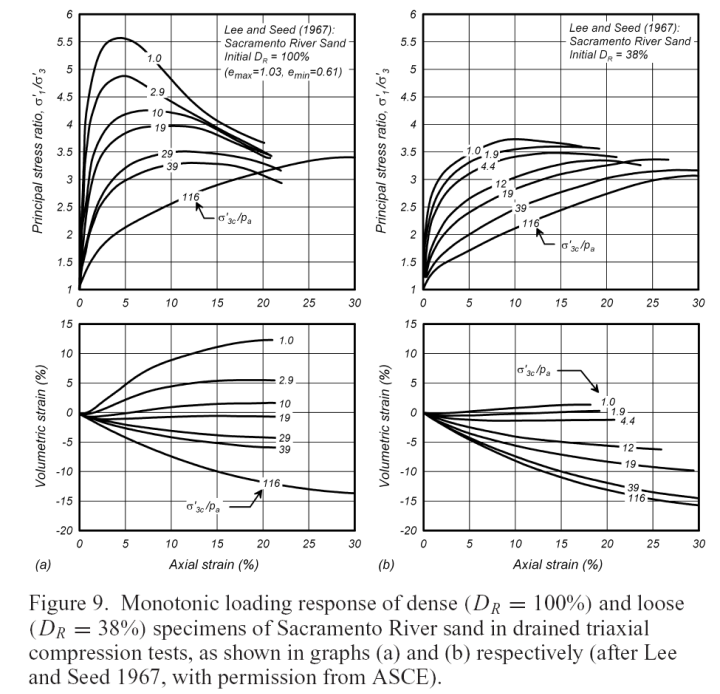

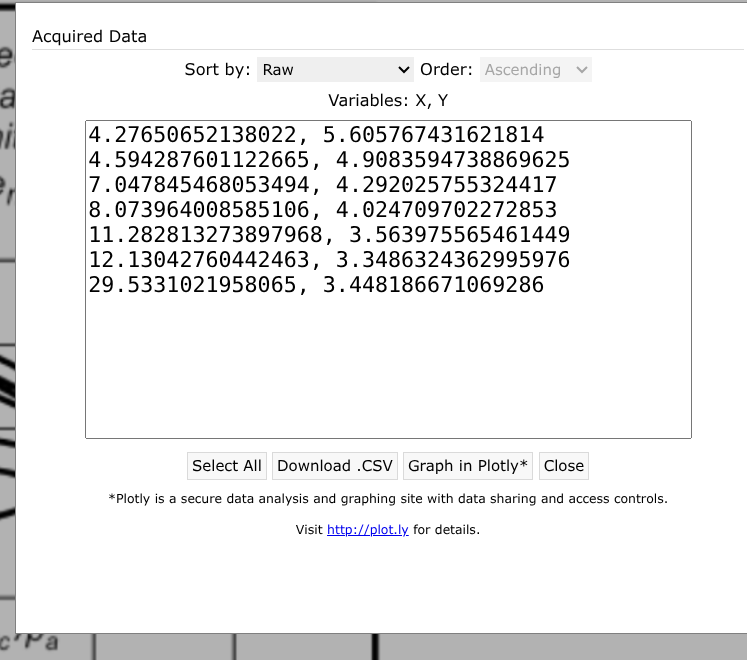

ic| cell_pressure/100: array([  1. ,   2.9,  10. ,  19. ,  29. ,  39. , 116. ])
ic| phi_values: array([44.18438515, 41.3774773 , 38.50928912, 36.86989765, 34.41738871,
                       32.336026  , 33.05573115])


array([44.18438515, 41.3774773 , 38.50928912, 36.86989765, 34.41738871,
       32.336026  , 33.05573115])

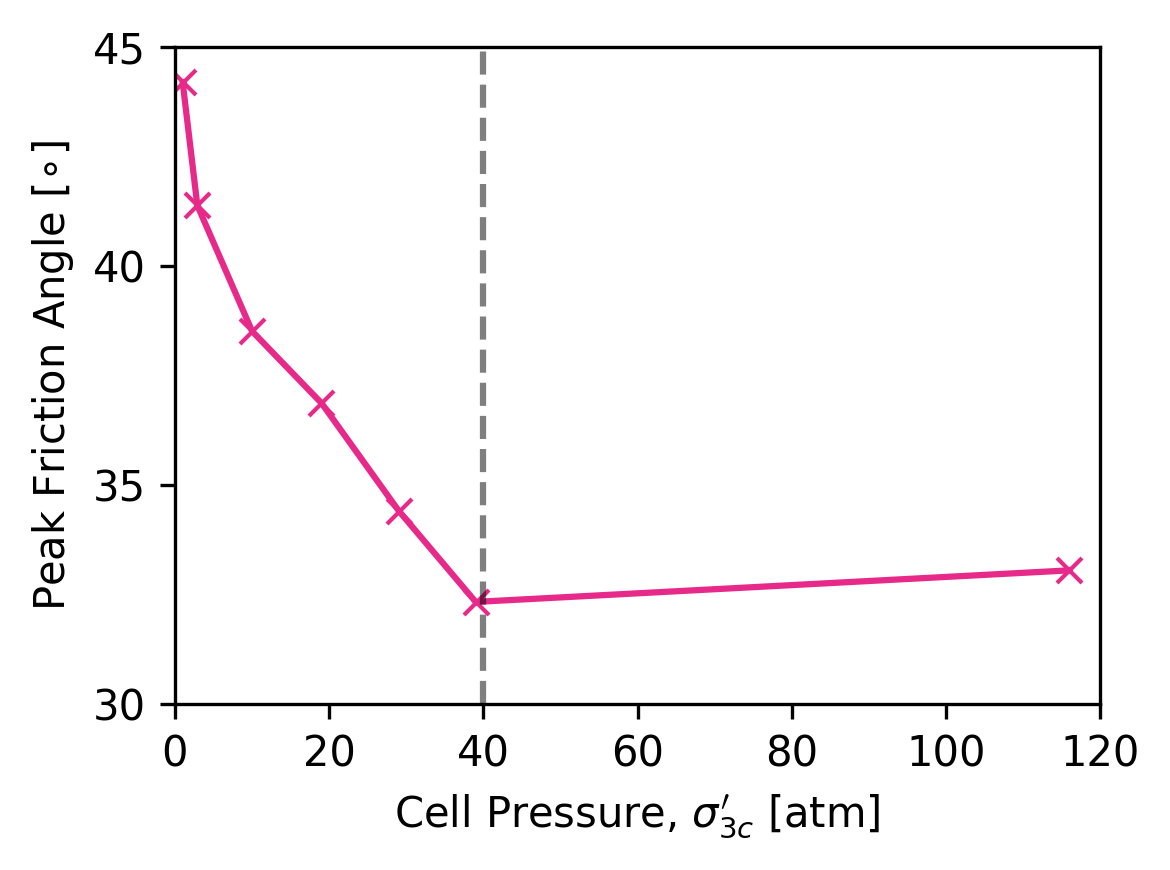

In [2]:
cell_pressure = 100 * np.array([1, 2.9,10,19,29, 39,116]) # normalized cell pressures
max_flow_number = np.array([5.6, 4.9, 4.3, 4.0, 3.6, 3.3, 3.4]) # max flow number for each cell pressure
phi = Symbol('phi')
phi_values = np.zeros(len(cell_pressure))
for index, N in enumerate(max_flow_number):
    phi_value = sy.deg(solve((((1+sy.sin(phi))/(1-sy.sin(phi)))-N), phi)[0]).evalf()
    phi_values[index] = phi_value

fig, ax = plt.subplots(figsize=(4,3), tight_layout=True, dpi=300)
ax.plot(cell_pressure/100, phi_values, 'x', color = '#e7298a', linestyle = '-')
ax.set_xlabel("Cell Pressure, $\\sigma_{3c}'$ [atm]")
ax.set_ylabel('Peak Friction Angle [$\\circ$]')
ax.vlines(40, 30, 45, color = 'black', linestyle = '--', alpha = 0.5)
ax.set_xlim(0, 120)
ax.set_ylim(30, 45)
ax.set_yticks(np.arange(30, 46, 5))

ic(cell_pressure/100)
ic(phi_values)

ic| radius: array([  230. ,   565.5,  1650. ,  2850. ,  3770. ,  4485. , 13920. ])
ic| center: array([  330. ,   855.5,  2650. ,  4750. ,  6670. ,  8385. , 25520. ])
ic| sigma_ff: array([  169.6969697 ,   481.69491525,  1622.64150943,  3040.        ,
                      4539.13043478,  5986.04651163, 17927.27272727])
ic| tau_ff.shape: (7,)


(array([    0.,  2500.,  5000.,  7500., 10000., 12500., 15000., 17500.,
        20000.]),
 [Text(0, 0.0, '0'),
  Text(0, 2500.0, '2500'),
  Text(0, 5000.0, '5000'),
  Text(0, 7500.0, '7500'),
  Text(0, 10000.0, '10000'),
  Text(0, 12500.0, '12500'),
  Text(0, 15000.0, '15000'),
  Text(0, 17500.0, '17500'),
  Text(0, 20000.0, '20000')])

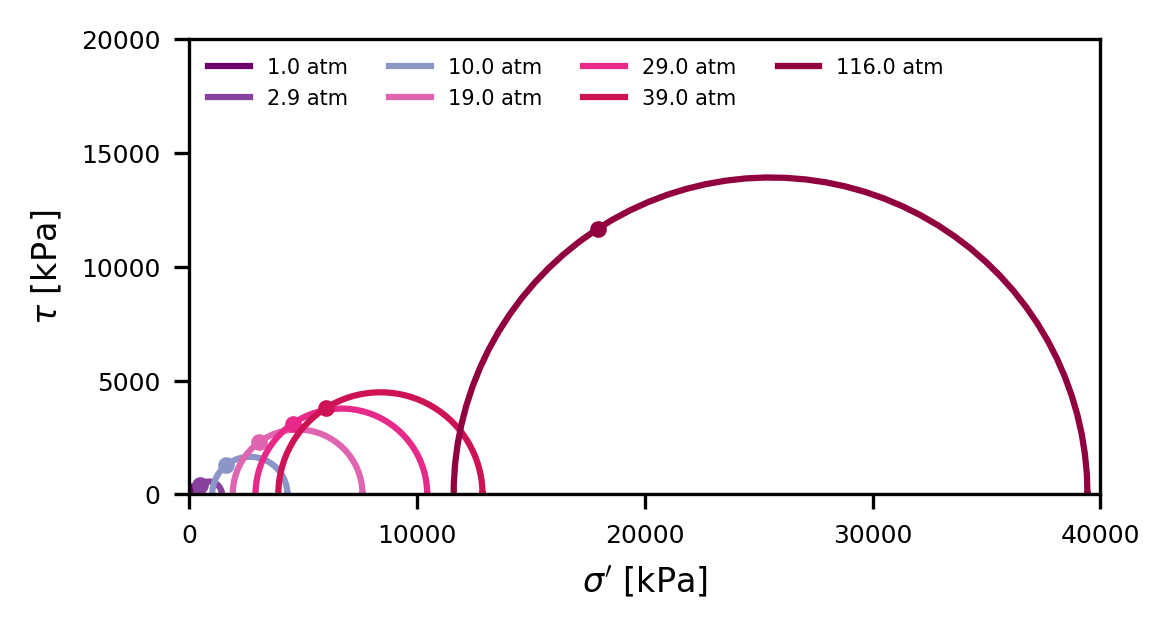

In [ ]:
major_principal = np.multiply(cell_pressure, max_flow_number)
# ic(major_principal)
deviatoric = major_principal - cell_pressure
# ic(deviatoric)

radius = np.divide(deviatoric, 2)
center = np.add(cell_pressure, major_principal)/2

ic(radius)
ic(center)

radians = np.linspace(0, 2*np.pi, 100)
radians_matrix = np.zeros((7, 100))

for i in range(7):
    radians_matrix[i] = radians

mohr_sigma = np.array([center[i] + radius[i]*np.cos(angle) for i in range(7) for angle in radians]).reshape(7, 100)
mohr_tau = np.array([radius[i]*np.sin(angle) for i in range(7) for angle in radians]).reshape(7, 100)

sigma_ff = np.array([(center[i] )- (radius[i]*np.cos((np.pi/2)- (phi_values[i]*np.pi/180))) for i in range(7)])
tau_ff = np.array([sigma_ff[i]*np.tan((phi_values[i]*np.pi/180)) for i in range(7)])

failure_points = np.array()


colors = ['#6e016b','#88419d', '#8c96c6', '#df65b0', '#e7298a', '#ce1256', '#91003f']

fig, ax = plt.subplots(figsize=(4,4), tight_layout=True, dpi=300)
for i in range(7):
    ax.plot(mohr_sigma[i], mohr_tau[i], color = colors[i], linestyle = '-', label = f"{cell_pressure[i]/100} atm")
    ax.plot(sigma_ff[i], tau_ff[i], '.', color = colors[i])

ax.set_xlabel("$\\sigma'$ [kPa]", fontsize = 8)
ax.set_ylabel('$\\tau$ [kPa]', fontsize = 8)
ax.legend(frameon = False, fontsize = 5, ncol = 4, loc = 'upper left')
ax.set_aspect('equal')
ax.set_ylim(0, 20000)
ax.set_xlim(0, 40000)
plt.xticks(fontsize = 6)
plt.yticks(fontsize = 6)